# Evaluation Notebook

This notebook loads trained weights, runs predictions, and writes the result plots used in the README.

In [1]:
import json
import os
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

small_data = Path("pm/dataset/asvspoof_small")
WEIGHTS = Path(os.environ.get("WEIGHTS", "pm/model/weights/model.pt"))
DATA_DIR = Path(os.environ.get("DATA_DIR", small_data / "flac" if small_data.exists() else "assets/example_audio"))
METADATA = Path(os.environ.get("METADATA", small_data / "trial_metadata.txt" if small_data.exists() else "assets/trial_metadata.txt"))
AUDIO_EXT = os.environ.get("AUDIO_EXT", ".flac" if small_data.exists() else ".wav")
FIG_DIR = Path("assets/eval_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("weights:", WEIGHTS)
print("data:", DATA_DIR)
print("metadata:", METADATA)

weights: pm/model/weights/model.pt
data: pm/dataset/asvspoof_small/flac
metadata: pm/dataset/asvspoof_small/trial_metadata.txt


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from pm.dataset.dataloader import ASVspoofAudioDataset, LABEL_TO_ID
from pm.model import AudioClassifier

id_to_label = {v: k for k, v in LABEL_TO_ID.items()}
full_ds = ASVspoofAudioDataset(protocol_path=METADATA, audio_dir=DATA_DIR, audio_ext=AUDIO_EXT)

use_heldout = small_data.exists() and os.environ.get("USE_HELDOUT", "1") == "1"
if use_heldout:
    n_val = int(len(full_ds) * 0.2)
    n_train = len(full_ds) - n_val
    _, ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(3))
else:
    ds = full_ds

loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioClassifier(num_classes=len(LABEL_TO_ID)).to(device)
model.load_state_dict(torch.load(WEIGHTS, map_location=device))
model.eval()

print("examples:", len(ds))
print("held out split:", use_heldout)
print("device:", device)

examples: 120
held out split: True
device: cpu


## Predictions

In [3]:
y_true, y_pred, y_score, specs = [], [], [], []

with torch.no_grad():
    for x, y in loader:
        logits = model(x.to(device))
        prob_fake = torch.softmax(logits, dim=1)[:, LABEL_TO_ID["fake"]].cpu()
        y_pred += logits.argmax(1).cpu().tolist()
        y_score += prob_fake.tolist()
        y_true += [int(v) for v in y]
        specs += [xi.squeeze(0).numpy() for xi in x.cpu()]

print("predicted:", len(y_pred))

predicted: 120


## Metrics

In [4]:
from pm.train_model import compute_eer

tp = sum(t == LABEL_TO_ID["fake"] and p == LABEL_TO_ID["fake"] for t, p in zip(y_true, y_pred))
tn = sum(t == LABEL_TO_ID["real"] and p == LABEL_TO_ID["real"] for t, p in zip(y_true, y_pred))
fp = sum(t == LABEL_TO_ID["real"] and p == LABEL_TO_ID["fake"] for t, p in zip(y_true, y_pred))
fn = sum(t == LABEL_TO_ID["fake"] and p == LABEL_TO_ID["real"] for t, p in zip(y_true, y_pred))

precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
accuracy = (tp + tn) / max(len(y_true), 1)
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
fake_indicator = [1 if t == LABEL_TO_ID["fake"] else 0 for t in y_true]
eer, eer_thr = compute_eer(y_score, fake_indicator)

metrics = {
    "eer": eer,
    "eer_threshold": eer_thr,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "confusion": {"tp": tp, "tn": tn, "fp": fp, "fn": fn},
    "n": len(y_true),
}

with (FIG_DIR / "metrics.json").open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

metrics

{'eer': 0.42428571428571427,
 'eer_threshold': 0.5165764093399048,
 'accuracy': 0.525,
 'precision': 0.4492753623188406,
 'recall': 0.62,
 'f1': 0.5210084033613446,
 'confusion': {'tp': 31, 'tn': 32, 'fp': 38, 'fn': 19},
 'n': 120}

## Confusion Matrix

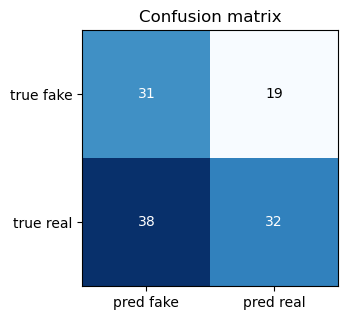

In [5]:
import matplotlib.pyplot as plt

cm = np.array([[tp, fn], [fp, tn]])
fig, ax = plt.subplots(figsize=(3.7, 3.3))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_xticklabels(["pred fake", "pred real"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["true fake", "true real"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion.png", dpi=150)
plt.show()

## Prediction Examples

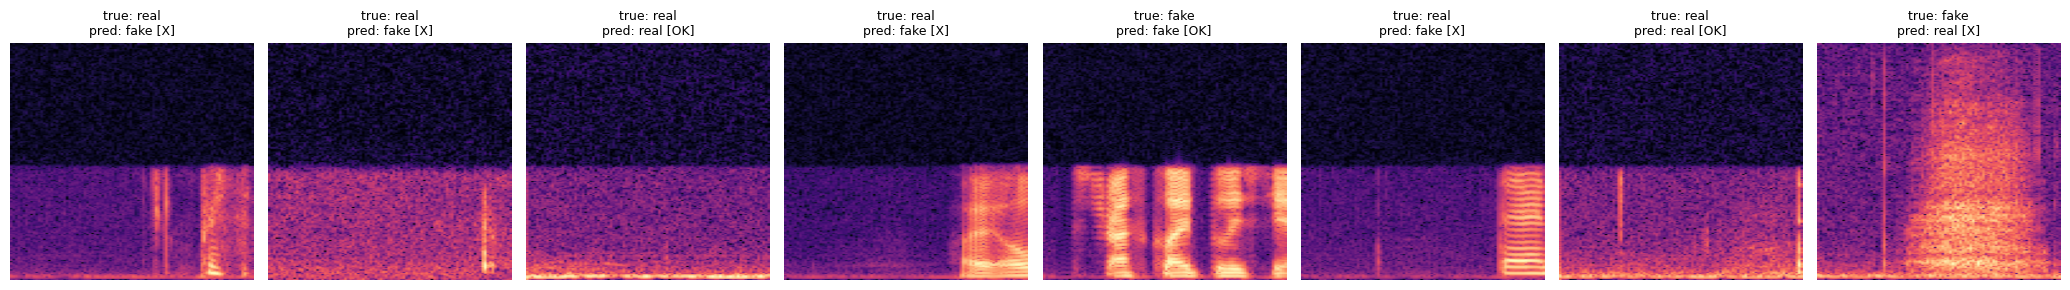

In [6]:
k = min(8, len(specs))
fig, axes = plt.subplots(1, k, figsize=(2.6 * k, 3))
axes = np.atleast_1d(axes)

for i, ax in enumerate(axes):
    ax.imshow(specs[i].T, aspect="auto", origin="lower", cmap="magma")
    ok = "OK" if y_true[i] == y_pred[i] else "X"
    title = f"true: {id_to_label[y_true[i]]}\npred: {id_to_label[y_pred[i]]} [{ok}]"
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "predictions.png", dpi=150)
plt.show()